# Energy Cost Analysis by Customer Segment

## tl;dr

This portfolio analysis examines 5,000 supplied customer records. Average energy cost is similar for residential and commercial customers (BRL 87.15 and BRL 86.35 respectively). Occupancy has a stronger observed association with cost (correlation 0.536) than building size (0.196). These are descriptive results, not causal estimates.

## Context & Methods

**Goal:** profile energy-cost patterns by customer type and region, and test which supplied numeric attributes are most strongly associated with cost.

**Method:** validate the source data, calculate descriptive summaries, compare group means, and use correlation as an exploratory relationship measure.

### Key assumptions and limits

- Each row is treated as one customer record.
- The source contains no time period, meter readings, tariff, weather, or building-efficiency variables. It therefore cannot support trend analysis or causal claims about cost drivers.
- `energy_cost_brl` is analysed as the supplied monetary outcome; it is not converted into a physical energy-consumption measure.

## Data

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path('../data/energy_consumption.csv')
OUTPUT_DIR = Path('../images')
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

energy = pd.read_csv(DATA_PATH)
energy.head()

,customer_id,customer_type,regions,building_size_m2,occupants,energy_cost_brl
0,CUSTOMER_0001,residential,Northeast,24,2,64.51
1,CUSTOMER_0002,commercial,Midwest,24,1,55.26
2,CUSTOMER_0003,commercial,Southeast,24,1,74.54
3,CUSTOMER_0004,residential,Northeast,45,4,147.06
4,CUSTOMER_0005,residential,Southeast,45,4,143.06


In [2]:
quality_summary = pd.DataFrame({
    'rows': [len(energy)],
    'columns': [energy.shape[1]],
    'missing_values': [int(energy.isna().sum().sum())],
    'duplicate_rows': [int(energy.duplicated().sum())],
})
quality_summary

,rows,columns,missing_values,duplicate_rows
0,5000,6,0,0


In [3]:
energy.dtypes.to_frame('data_type')

,data_type
customer_id,object
customer_type,object
regions,object
building_size_m2,int64
occupants,int64
energy_cost_brl,float64


## Results

In [4]:
overall_summary = energy[['building_size_m2', 'occupants', 'energy_cost_brl']].describe().T
overall_summary

,count,mean,std,min,25%,50%,75%,max
building_size_m2,"5,000.00",39.58,17.52,17.00,24.00,45.00,45.00,77.00
occupants,"5,000.00",2.30,1.03,1.00,1.00,2.00,3.00,4.00
energy_cost_brl,"5,000.00",86.87,24.38,52.52,68.56,83.72,98.24,158.61


In [5]:
segment_summary = (
    energy.groupby('customer_type', as_index=False)
    .agg(
        customer_records=('customer_id', 'size'),
        average_energy_cost_brl=('energy_cost_brl', 'mean'),
        median_energy_cost_brl=('energy_cost_brl', 'median'),
        average_building_size_m2=('building_size_m2', 'mean'),
        average_occupants=('occupants', 'mean'),
    )
    .sort_values('average_energy_cost_brl', ascending=False)
)
segment_summary

,customer_type,customer_records,average_energy_cost_brl,median_energy_cost_brl,average_building_size_m2,average_occupants
1,residential,3261,87.15,83.78,39.66,2.33
0,commercial,1739,86.35,83.63,39.42,2.26


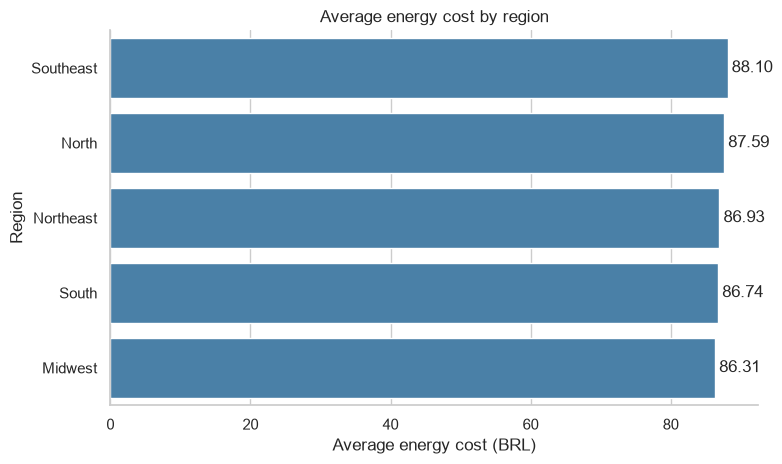

,regions,customer_records,average_energy_cost_brl
4,Southeast,481,88.10
1,North,759,87.59
2,Northeast,1266,86.93
3,South,482,86.74
0,Midwest,2012,86.31


In [6]:
regional_summary = (
    energy.groupby('regions', as_index=False)
    .agg(
        customer_records=('customer_id', 'size'),
        average_energy_cost_brl=('energy_cost_brl', 'mean'),
    )
    .sort_values('average_energy_cost_brl', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=regional_summary, x='average_energy_cost_brl', y='regions', color='#3B82B6', ax=ax)
ax.set(title='Average energy cost by region', xlabel='Average energy cost (BRL)', ylabel='Region')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
sns.despine()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'average_cost_by_region.png', dpi=180, bbox_inches='tight')
plt.show()
regional_summary

/var/folders/x_/sxj4k3ld4rxcm1dw0lp6g5q80000gn/T/ipykernel_70983/2989651301.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=energy, x='customer_type', y='energy_cost_brl', palette=['#4C78A8', '#F58518'], ax=ax)


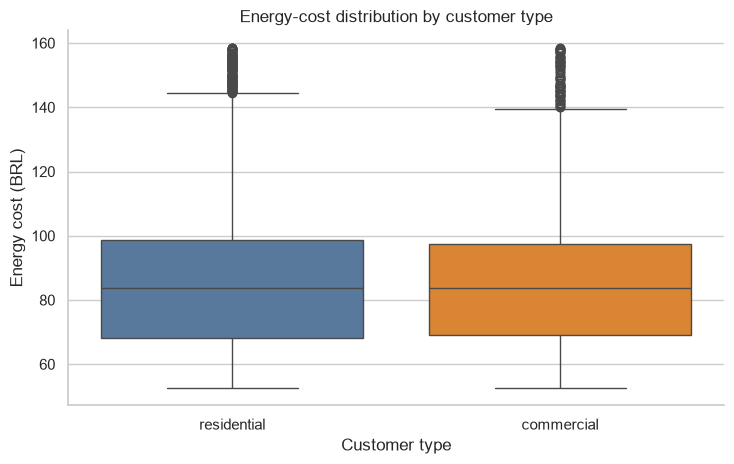

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
sns.boxplot(data=energy, x='customer_type', y='energy_cost_brl', palette=['#4C78A8', '#F58518'], ax=ax)
ax.set(title='Energy-cost distribution by customer type', xlabel='Customer type', ylabel='Energy cost (BRL)')
sns.despine()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'cost_distribution_by_customer_type.png', dpi=180, bbox_inches='tight')
plt.show()

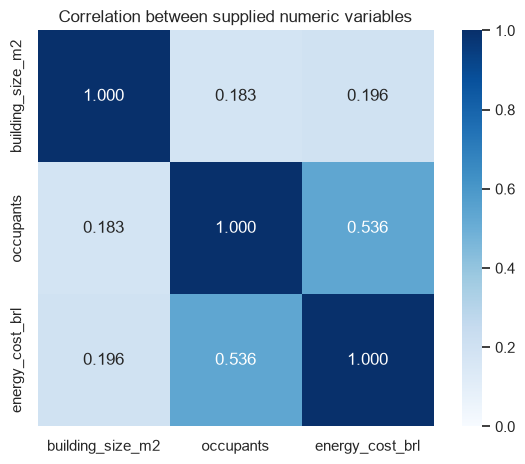

,building_size_m2,occupants,energy_cost_brl
building_size_m2,1.00,0.18,0.20
occupants,0.18,1.00,0.54
energy_cost_brl,0.20,0.54,1.00


In [8]:
numeric_columns = ['building_size_m2', 'occupants', 'energy_cost_brl']
correlation = energy[numeric_columns].corr()

fig, ax = plt.subplots(figsize=(6.2, 4.8))
sns.heatmap(correlation, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1, square=True, ax=ax)
ax.set_title('Correlation between supplied numeric variables')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'numeric_correlation.png', dpi=180, bbox_inches='tight')
plt.show()
correlation

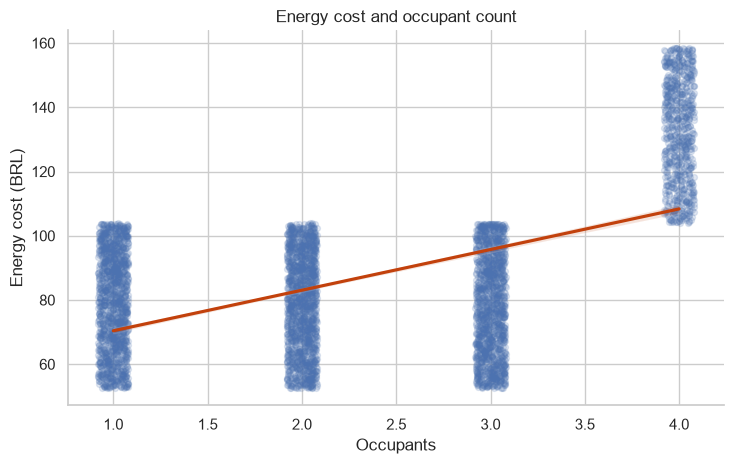

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
sns.regplot(
    data=energy, x='occupants', y='energy_cost_brl',
    x_jitter=0.08, scatter_kws={'alpha': 0.16, 's': 18}, line_kws={'color': '#C2410C'}, ax=ax
)
ax.set(title='Energy cost and occupant count', xlabel='Occupants', ylabel='Energy cost (BRL)')
sns.despine()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'cost_vs_occupants.png', dpi=180, bbox_inches='tight')
plt.show()

## Takeaways

1. The dataset passed basic checks: 5,000 records, no missing values, and no exact duplicate rows.
2. Mean costs are close across customer type, so this dataset does not show a large residential-versus-commercial difference in the supplied cost variable.
3. Regional mean costs vary only modestly; the Southeast has the highest mean (BRL 88.10) and the Midwest the lowest (BRL 86.31).
4. Occupant count has the strongest exploratory correlation with cost (0.536). Building size has a weaker correlation (0.196).

Further analysis would need time, tariff, consumption, and weather data before making operational recommendations or causal conclusions.